In [83]:
import imageio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

x = np.random.randn(300)
b, a = butter(4, 0.2)
y = filtfilt(b, a, x)

video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017892.avi'
output_video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017892_overlay.avi'

In [84]:

reader = imageio.get_reader(video_path)
meta = reader.get_meta_data()
fps = meta.get("fps", 30)
W, H = meta["size"]

out = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (W, H)
)

# ============================================================
# ROI – Image Center
# ============================================================
roi_w = int(0.45 * W)
roi_h = int(0.45 * H)
roi_x = (W - roi_w) // 2
roi_y = (H - roi_h) // 2

# ============================================================
# Parameters
# ============================================================
BLUE_THRESHOLD = 15
MIN_BAND_HEIGHT = 20

# Camera / geometric
FOV_V_DEG = 94.0          # GoPro 7 Black vertical FOV (Wide)
CAMERA_DEPTH = 0.30       # m
DISTANCE_TO_SWIMMER = 1.0 # m

# ============================================================
# Time Series
# ============================================================
times = []
body_centers_px = []
body_errors_px = []

# ============================================================
# Frame loop
# ============================================================
for idx, frame_rgb in enumerate(reader):
    frame = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    roi = frame[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]

    # --- "blue-ness" measure
    B, G, R = cv2.split(roi)
    blue_score = B.astype(np.int16) - ((R.astype(np.int16) + G.astype(np.int16)) // 2)

    column_centers = []

    # --- Water segmentation water body, water per column
    for x in range(0, roi_w, 2):
        col = blue_score[:, x]
        is_blue = col > BLUE_THRESHOLD
        transitions = np.diff(is_blue.astype(np.int8))

        upper = np.where(transitions == -1)[0]
        lower = np.where(transitions == 1)[0]

        if len(upper) == 0 or len(lower) == 0:
            continue

        y_top = upper[0]
        y_bottom = lower[-1]

        if y_bottom - y_top < MIN_BAND_HEIGHT:
            continue

        y_center = (y_top + y_bottom) // 2
        column_centers.append((x, y_top, y_bottom, y_center))

    if len(column_centers) < 10:
        out.write(frame)
        continue

    centers_y = np.array([c[3] for c in column_centers])
    mean_center = np.mean(centers_y)
    std_center = np.std(centers_y)

    global_center_y = mean_center + roi_y

    times.append(idx / fps)
    body_centers_px.append(global_center_y)
    body_errors_px.append(std_center)

    # ========================================================
    # OVERLAY – debug video
    # ========================================================
    cv2.rectangle(
        frame,
        (roi_x, roi_y),
        (roi_x + roi_w, roi_y + roi_h),
        (255, 255, 0),
        2
    )

    for x, yt, yb, yc in column_centers[::5]:
        cv2.line(
            frame,
            (roi_x + x, roi_y + yt),
            (roi_x + x, roi_y + yb),
            (0, 255, 0),
            1
        )
        cv2.circle(
            frame,
            (roi_x + x, roi_y + yc),
            2,
            (0, 0, 255),
            -1
        )

    cv2.line(
        frame,
        (roi_x, int(global_center_y)),
        (roi_x + roi_w, int(global_center_y)),
        (0, 255, 255),
        2
    )

    out.write(frame)

reader.close()
out.release()

In [85]:
# ============================================================
# NUMPY
# ============================================================
times = np.array(times)
body_centers_px = np.array(body_centers_px)
body_errors_px = np.array(body_errors_px)

# ============================================================
# PIXEL → MÉLYSÉG TRANSZFORMÁCIÓ
# ============================================================
FOV_V = np.deg2rad(FOV_V_DEG)

theta = ((body_centers_px - H / 2) / H) * FOV_V
body_depth_m = CAMERA_DEPTH + DISTANCE_TO_SWIMMER * np.tan(theta)

# ============================================================
# LOW-PASS SZŰRŐ (TEST MOZGÁS)
# ============================================================
def butter_lowpass(signal, cutoff_hz, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyq, btype="low")
    return filtfilt(b, a, signal)

body_depth_lp = butter_lowpass(
    body_depth_m,
    cutoff_hz=0.3,
    fs=fps
)

# ============================================================
# KARCSAPÁS JEL + PEAK DETEKCIÓ
# ============================================================
stroke_signal = body_depth_m - body_depth_lp

peaks, _ = find_peaks(
    stroke_signal,
    distance=int(0.45 * fps),
    prominence=0.02
)

stroke_rate = len(peaks) / (times[-1] - times[0]) * 60


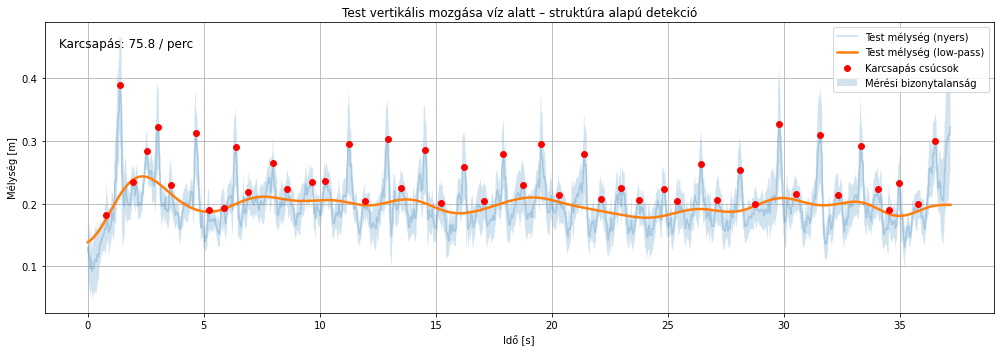

In [86]:
# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(14, 5))

plt.plot(
    times,
    body_depth_m,
    alpha=0.25,
    label="Test mélység (nyers)"
)

plt.plot(
    times,
    body_depth_lp,
    linewidth=2.5,
    label="Test mélység (low-pass)"
)

plt.scatter(
    times[peaks],
    body_depth_m[peaks],
    color="red",
    s=35,
    zorder=5,
    label="Karcsapás csúcsok"
)

depth_error_m = body_errors_px * DISTANCE_TO_SWIMMER / H

plt.fill_between(
    times,
    body_depth_m - depth_error_m,
    body_depth_m + depth_error_m,
    alpha=0.2,
    label="Mérési bizonytalanság"
)

plt.text(
    0.015,
    0.95,
    f"Karcsapás: {stroke_rate:.1f} / perc",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.xlabel("Idő [s]")
plt.ylabel("Mélység [m]")
plt.title("Test vertikális mozgása víz alatt – struktúra alapú detekció")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

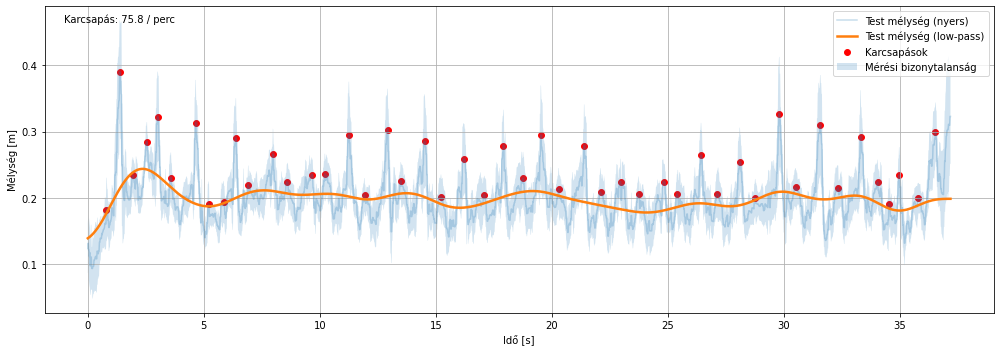

In [101]:
import imageio
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ============================================================
# VIDEO PATHS
# ============================================================
video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017892.avi'
output_video_path = 'C:\\Users\\user\\Desktop\\MotionReconstruction\\GH017892_overlay.avi'

# ============================================================
# VIDEO READER
# ============================================================
reader = imageio.get_reader(video_path)
meta = reader.get_meta_data()
fps = meta.get("fps", 30)
W, H = meta["size"]

# ============================================================
# ROI – KÉP KÖZEPE
# ============================================================
roi_w = int(0.45 * W)
roi_h = int(0.45 * H)
roi_x = (W - roi_w) // 2
roi_y = (H - roi_h) // 2

# ============================================================
# PARAMÉTEREK
# ============================================================
BLUE_THRESHOLD = 15
MIN_BAND_HEIGHT = 20

# Buborék (fehér) – SZIGORÚBB
WHITE_SAT_MAX = 25
WHITE_VAL_MIN = 210
WHITE_BLUE_MAX = 140

# Kamera / geometria
FOV_V_DEG = 94.0
CAMERA_DEPTH = 0.30
DISTANCE_TO_SWIMMER = 1.0

# ============================================================
# IDŐSOROK
# ============================================================
times = []
body_centers_px = []
body_errors_px = []
column_cache = [] 
frames_cache = []

# ============================================================
# FRAME LOOP
# ============================================================
for idx, frame_rgb in enumerate(reader):
    frame = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    frames_cache.append(frame.copy())

    roi = frame[roi_y:roi_y + roi_h, roi_x:roi_x + roi_w]

    # --- blue-ness (RGB)
    B, G, R = cv2.split(roi)
    blue_score = B.astype(np.int16) - ((R.astype(np.int16) + G.astype(np.int16)) // 2)
    is_blue = blue_score > BLUE_THRESHOLD

    # --- buborék (HSV)
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    _, S, V = cv2.split(hsv)

    is_white = (
        (S < WHITE_SAT_MAX) &
        (V > WHITE_VAL_MIN) &
        (B < WHITE_BLUE_MAX)
    )

    # --- víz maszk
    is_water = is_blue | is_white

    column_centers = []

    for x in range(0, roi_w, 2):
        col = is_water[:, x]
        transitions = np.diff(col.astype(np.int8))

        upper = np.where(transitions == -1)[0]
        lower = np.where(transitions == 1)[0]

        if len(upper) == 0 or len(lower) == 0:
            continue

        y_top = upper[0]
        y_bottom = lower[-1]

        if y_bottom - y_top < MIN_BAND_HEIGHT:
            continue

        y_center = (y_top + y_bottom) // 2
        column_centers.append((x, y_top, y_bottom, y_center))

    if len(column_centers) < 10:
        body_centers_px.append(np.nan)
        body_errors_px.append(np.nan)
        column_cache.append(None)
        times.append(idx / fps)
        continue

    centers_y = np.array([c[3] for c in column_centers])
    mean_center = np.mean(centers_y)
    std_center = np.std(centers_y)

    global_center_y = mean_center + roi_y

    times.append(idx / fps)
    body_centers_px.append(global_center_y)
    body_errors_px.append(std_center)
    column_cache.append(column_centers)

# ============================================================
# NUMPY
# ============================================================
times = np.array(times)
body_centers_px = np.array(body_centers_px)
body_errors_px = np.array(body_errors_px)

valid = ~np.isnan(body_centers_px)
times = times[valid]
body_centers_px = body_centers_px[valid]
body_errors_px = body_errors_px[valid]

# ============================================================
# PIXEL → MÉLYSÉG
# ============================================================
FOV_V = np.deg2rad(FOV_V_DEG)
theta = ((body_centers_px - H / 2) / H) * FOV_V
body_depth_m = CAMERA_DEPTH + DISTANCE_TO_SWIMMER * np.tan(theta)

# ============================================================
# LOW-PASS
# ============================================================
def butter_lowpass(signal, cutoff_hz, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyq, btype="low")
    return filtfilt(b, a, signal)

body_depth_lp = butter_lowpass(body_depth_m, 0.3, fps)

# ============================================================
# MÉLYSÉG → PIXEL (fehér vonalhoz)
# ============================================================
theta_lp = np.arctan((body_depth_lp - CAMERA_DEPTH) / DISTANCE_TO_SWIMMER)
body_center_lp_px = (theta_lp / FOV_V) * H + H / 2

# ============================================================
# OUTPUT VIDEÓ
# ============================================================
out = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (W, H)
)

lp_idx = 0

for i, frame in enumerate(frames_cache):
    if i >= len(times):
        out.write(frame)
        continue

    # ROI box
    cv2.rectangle(
        frame,
        (roi_x, roi_y),
        (roi_x + roi_w, roi_y + roi_h),
        (255, 255, 0),
        2
    )

    # ===============================
    # ZÖLD CSÍKOK + PIROS PONTOK
    # ===============================
    cols = column_cache[i]
    if cols is not None:
        for x, yt, yb, yc in cols[::5]:
            cv2.line(
                frame,
                (roi_x + x, roi_y + yt),
                (roi_x + x, roi_y + yb),
                (0, 255, 0),
                1
            )
            cv2.circle(
                frame,
                (roi_x + x, roi_y + yc),
                2,
                (0, 0, 255),
                -1
            )

    # per-frame (sárga)
    y_raw = int(body_centers_px[lp_idx])
    cv2.line(
        frame,
        (roi_x, y_raw),
        (roi_x + roi_w, y_raw),
        (0, 255, 255),
        2
    )

    # simított (fehér)
    y_lp = int(body_center_lp_px[lp_idx])
    cv2.line(
        frame,
        (roi_x, y_lp),
        (roi_x + roi_w, y_lp),
        (255, 255, 255),
        2
    )

    lp_idx += 1
    out.write(frame)

out.release()
reader.close()

# ============================================================
# PEAK DETECTION + PLOT (VÁLTOZATLAN)
# ============================================================
stroke_signal = body_depth_m - body_depth_lp

peaks, _ = find_peaks(
    stroke_signal,
    distance=int(0.45 * fps),
    prominence=0.02
)

stroke_rate = len(peaks) / (times[-1] - times[0]) * 60

plt.figure(figsize=(14, 5))
plt.plot(times, body_depth_m, alpha=0.25, label="Test mélység (nyers)")
plt.plot(times, body_depth_lp, linewidth=2.5, label="Test mélység (low-pass)")
plt.scatter(times[peaks], body_depth_m[peaks], color="red", s=35, label="Karcsapások")

depth_error_m = body_errors_px * DISTANCE_TO_SWIMMER / H
plt.fill_between(
    times,
    body_depth_m - depth_error_m,
    body_depth_m + depth_error_m,
    alpha=0.2,
    label="Mérési bizonytalanság"
)

plt.text(
    0.02, 0.95,
    f"Karcsapás: {stroke_rate:.1f} / perc",
    transform=plt.gca().transAxes
)

plt.xlabel("Idő [s]")
plt.ylabel("Mélység [m]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
